<a href="https://colab.research.google.com/github/ardiyoga/ardiyoga/blob/main/Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Regression Problem

### Exploring Data

In [42]:
!wget --no-check-certificate https://github.com/lukpras/datasets/raw/main/student-test-score.csv

--2024-09-04 06:16:44--  https://github.com/lukpras/datasets/raw/main/student-test-score.csv
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/lukpras/datasets/main/student-test-score.csv [following]
--2024-09-04 06:16:44--  https://media.githubusercontent.com/media/lukpras/datasets/main/student-test-score.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6061 (5.9K) [text/plain]
Saving to: ‘student-test-score.csv.1’

student-test-score. 100%[===================>]   5.92K  --.-KB/s    in 0s      

2024-09-04 06:16:44 (52.9 MB/s) - ‘student-test-score.csv.1’ saved [6061/6061]



In [43]:
import pandas as pd
import os

In [44]:
os.getcwd()

'/content'

In [45]:
os.listdir('/content/sample_data')

['anscombe.json',
 'README.md',
 'mnist_test.csv',
 'mnist_train_small.csv',
 'california_housing_train.csv',
 'california_housing_test.csv']

In [46]:
df = pd.read_csv('student-test-score.csv')

In [47]:
df.head()

,Pysics,Science,Statistics,Math
0,50.0,32,60.0,68
1,76.0,39,69.0,67
2,52.0,38,56.0,57
3,NaN,50,NaN,91
4,80.0,63,91.0,82


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466 entries, 0 to 465
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pysics      447 non-null    float64
 1   Science     465 non-null    object 
 2   Statistics  461 non-null    float64
 3   Math        466 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 14.7+ KB


In [49]:
df.Science.sort_values()

,Science
441,10
290,10
265,100
323,103
163,11
...,...
246,99
233,Bandung
13,Diana
94,Mirana


In [50]:
# ekstrak nilai numerik pada kolom Science
science = df['Science'].str.extract(r"(\D+)|(\d+)$")
science.rename(columns={0:'String', 1:'Numerik'}, inplace=True)
science_s = science['String'].dropna().to_frame().reset_index()
science_s

,index,String
0,13,Diana
1,94,Mirana
2,233,Bandung
3,320,.


In [51]:
# save ke dalam csv
science_s.to_csv("nilai string dalam kolom Science.csv")

In [52]:
# nilai numerik pada kolom Science
science_n = science['Numerik'].dropna().to_frame().reset_index()
science_n.tail(2)

,index,Numerik
459,464,34
460,465,30


In [53]:
print("Nilai numerik ", len(science_n))
print("Nilai string ", len(science_s))
print("Nilai null ", df.Science.isnull().sum())

Nilai numerik  461
Nilai string  4
Nilai null  1


In [54]:
# Merubah nilai string menjadi nilai null/ #NA/ NaN
df['Science'] = pd.to_numeric(df['Science'], errors='coerce')
df.Science.dtype

dtype('float64')

In [55]:
# cek nilai null
df.isnull().sum()

,0
Pysics,19
Science,4
Statistics,5
Math,0


In [56]:
# Mengisi nulai null pada setiap kolom dengan nilai rata2
df['Pysics'] = df['Pysics'].fillna(df['Pysics'].mean())
df['Statistics'] = df['Statistics'].fillna(df['Statistics'].mean())
df['Science'] = df['Science'].fillna(df['Science'].mean())

In [57]:
df.isnull().sum()

,0
Pysics,0
Science,0
Statistics,0
Math,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466 entries, 0 to 465
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pysics      466 non-null    float64
 1   Science     466 non-null    float64
 2   Statistics  466 non-null    float64
 3   Math        466 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 14.7 KB


In [59]:
# Merubah tipe data dari float/decimal menjadi interger
df['Pysics'] = df['Pysics'].astype(int)
df['Statistics'] = df['Statistics'].astype(int)
df['Science'] = df['Science'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466 entries, 0 to 465
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Pysics      466 non-null    int64
 1   Science     466 non-null    int64
 2   Statistics  466 non-null    int64
 3   Math        466 non-null    int64
dtypes: int64(4)
memory usage: 14.7 KB


In [60]:
# Cek nilai statistik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pysics,466.0,70.210300,13.349511,13.0,61.0,70.0,80.0,99.0
Science,466.0,65.293991,22.728729,3.0,48.0,70.0,84.0,103.0
Statistics,466.0,74.253219,13.278175,14.0,65.0,74.0,83.0,107.0
Math,466.0,74.540773,11.424528,22.0,67.0,74.0,83.0,99.0


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

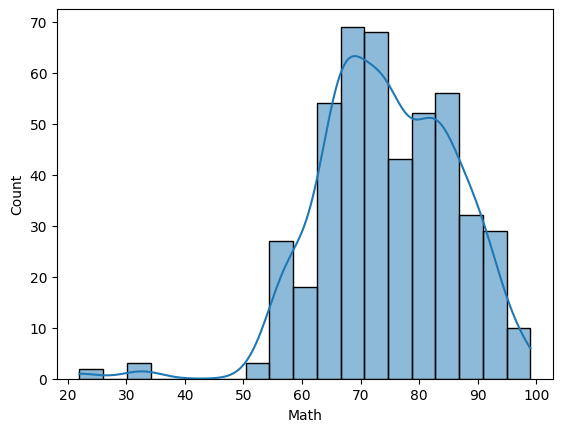

In [62]:
fig = sns.histplot(data=df, x='Math', kde=True).get_figure()
plt.savefig("histogram math.png")

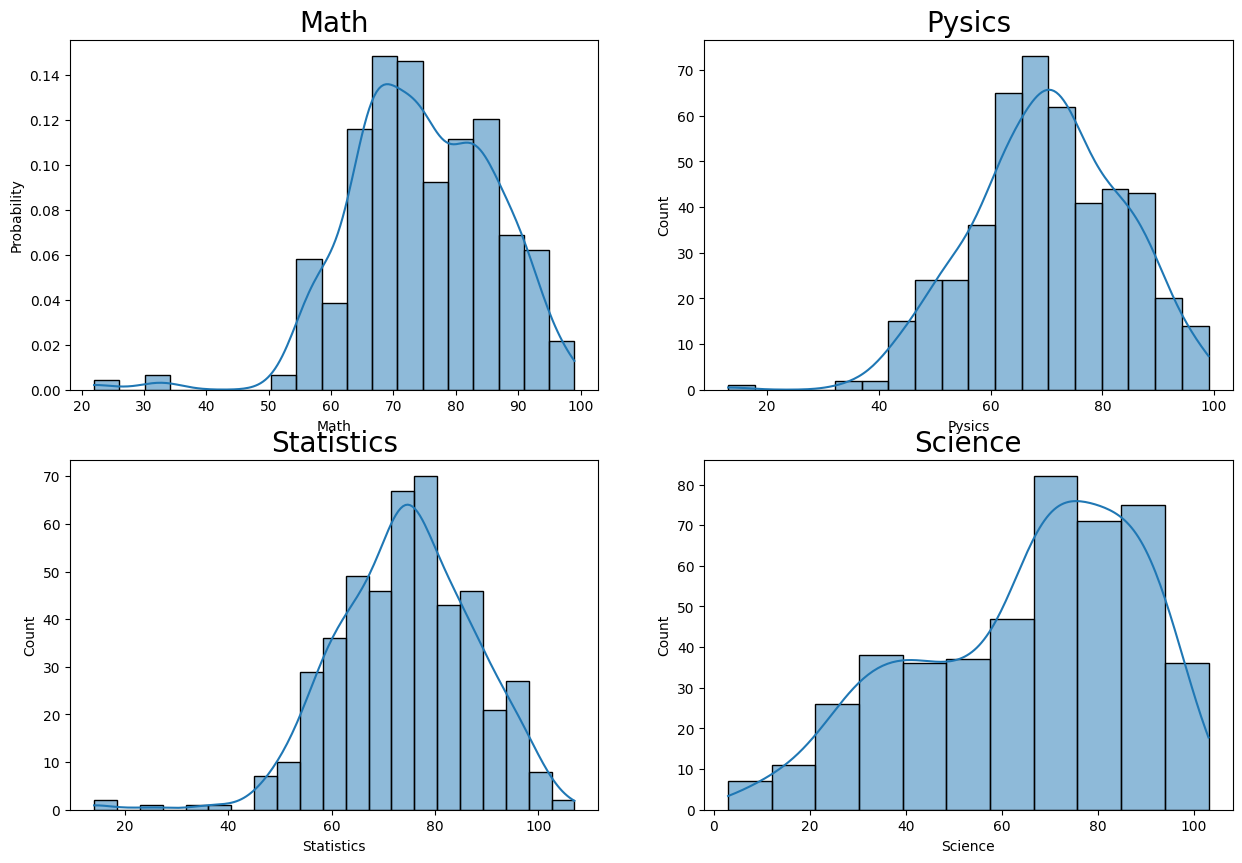

In [63]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(data=df, x='Math', kde=True, stat="probability", ax=axis[0,0])
sns.histplot(data=df, x='Pysics', kde=True, ax=axis[0,1])
sns.histplot(data=df, x='Statistics', kde=True, ax=axis[1,0])
sns.histplot(data=df, x='Science', kde=True, ax=axis[1,1])
axis[0,0].set_title("Math", size=20)
axis[0,1].set_title("Pysics", size=20)
axis[1,0].set_title("Statistics", size=20)
axis[1,1].set_title("Science", size=20)
fig.savefig("histogram semua fitur.png")

<Axes: xlabel='Science', ylabel='Math'>

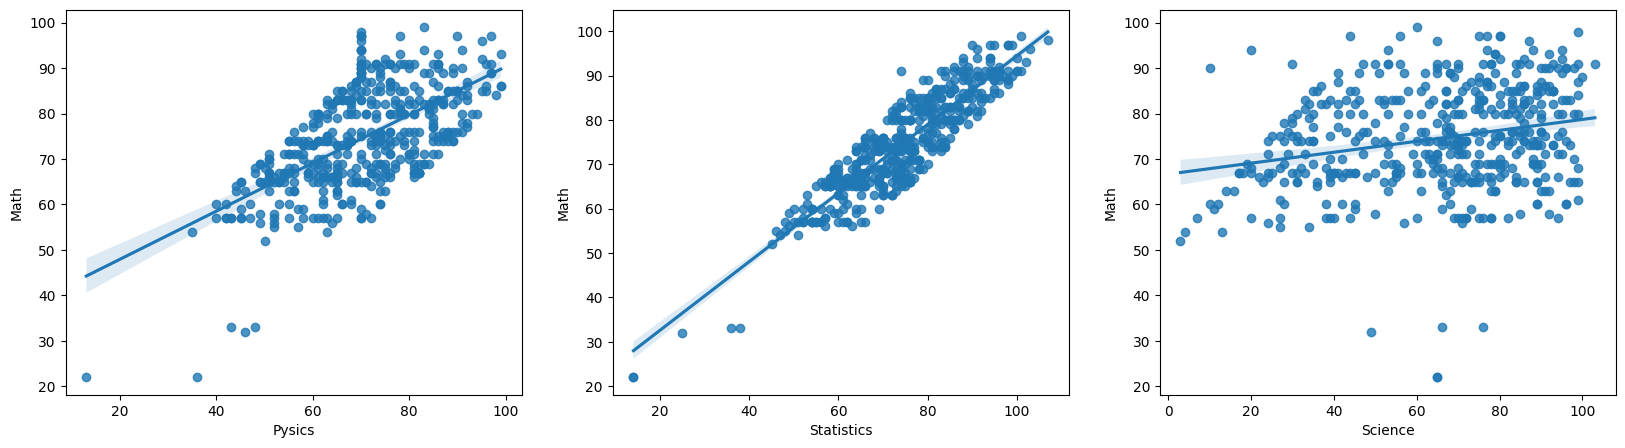

In [64]:
# Membuat scatterplot setiap fitur (selain Math) terhadap target (Math)
fig, axis = plt.subplots(1, 3, figsize=(20, 5))
sns.regplot(data=df, x='Pysics', y='Math', ax=axis[0])
sns.regplot(data=df, x='Statistics', y='Math', ax=axis[1])
sns.regplot(data=df, x='Science', y='Math', ax=axis[2])

In [65]:
# parameter hubungan setiap variabel
df.corr()

,Pysics,Science,Statistics,Math
Pysics,1.000000,0.108443,0.532841,0.618390
Science,0.108443,1.000000,0.248436,0.239506
Statistics,0.532841,0.248436,1.000000,0.898186
Math,0.618390,0.239506,0.898186,1.000000


In [66]:
# parameter ketinggian sebaran data
df.kurt()

,0
Pysics,0.080990
Science,-0.581582
Statistics,1.338337
Math,1.648008


In [67]:
# parameter kemiringan sebaran data
df.skew()

,0
Pysics,-0.247023
Science,-0.574654
Statistics,-0.486982
Math,-0.561298


<Axes: xlabel='Math'>

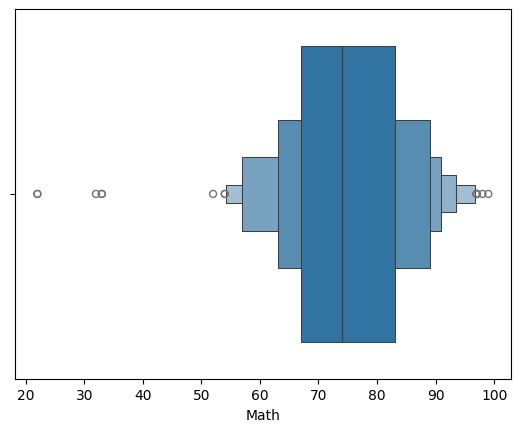

In [68]:
sns.boxenplot(data=df, x='Math')

In [69]:
# perhitungan batas atas dan batas bawah untuk 2 variable berdsarkan Inter Quantile Range (IQR)
# untuk menghilangkan outlier (nilai extreme)
q1_math = df['Math'].quantile(0.25)
q3_math = df['Math'].quantile(0.75)
iqr_math = q3_math - q1_math
lcl_math = q1_math - 1.5 * iqr_math
ucl_math = q3_math + 1.5 * iqr_math

q1_sc = df['Science'].quantile(0.25)
q3_sc = df['Science'].quantile(0.75)
iqr_sc = q3_sc - q1_sc
lcl_sc = q1_sc - 1.5 * iqr_sc
ucl_sc = q3_sc + 1.5 * iqr_sc

print("Batas bawah Math ", lcl_math)
print("Batas atas Math ", ucl_math)
print("Batas bawah Science ", lcl_sc)
print("Batas atas Science ", ucl_sc)

Batas bawah Math  43.0
Batas atas Math  107.0
Batas bawah Science  -6.0
Batas atas Science  138.0


In [70]:
# cek perhitungan batas atas dan bawah untuk nilai math dengan standar deviasi
lcl_mt = df['Math'].mean() - 3 * df['Math'].std()
ucl_mt = df['Math'].mean() + 3 * df['Math'].std()
print("Batas bawah Math ", lcl_mt)
print("Batas atas Math ", ucl_mt)

Batas bawah Math  40.26718861370732
Batas atas Math  108.81435645067036


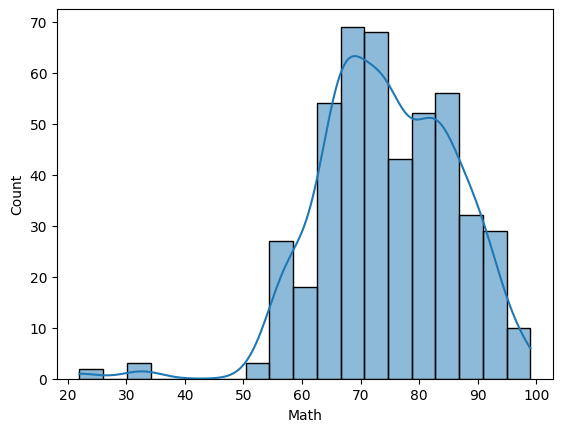

In [71]:
fig = sns.histplot(data=df, x='Math', kde=True).get_figure()

In [72]:
# cek perhitungan batas atas dan bawah untuk 2 variabel berdasarkan standar deviasi (STD)
# untuk menghilangkan outlier (nilai extereme)
lcl_py = df['Pysics'].mean() - 3 * df['Pysics'].std()
ucl_py = df['Pysics'].mean() + 3 * df['Pysics'].std()

lcl_st = df['Statistics'].mean() - 3 * df['Statistics'].std()
ucl_st = df['Statistics'].mean() + 3 * df['Statistics'].std()

print("Batas bawah Pysics ", lcl_py)
print("Batas atas Pysics ", ucl_py)
print("Batas bawah Pysics ", lcl_st)
print("Batas atas Pysics ", ucl_st)

Batas bawah Pysics  30.161767640319823
Batas atas Pysics  110.25883321804926
Batas bawah Pysics  34.41869337323254
Batas atas Pysics  114.0877443950078


In [73]:
import numpy as np

In [75]:
# menghilangkan outliner untuk setiap variabel
upper_mt = np.where(df['Math'] > ucl_math)
lower_mt = np.where(df['Math'] < lcl_math)
df.drop(upper_mt[0], inplace=True)
df.drop(lower_mt[0], inplace=True)

upper_sc = np.where(df['Science'] > ucl_sc)
lower_sc = np.where(df['Science'] < lcl_sc)
df.drop(upper_sc[0], inplace=True)
df.drop(lower_sc[0], inplace=True)

upper_py = np.where(df['Pysics'] > ucl_py)
lower_py = np.where(df['Pysics'] < lcl_py)
df.drop(upper_py[0], inplace=True)
df.drop(lower_py[0], inplace=True)

upper_st = np.where(df['Statistics'] > ucl_st)
lower_st = np.where(df['Statistics'] < lcl_st)
df.drop(upper_st[0], inplace=True)
df.drop(lower_st[0], inplace=True)

In [78]:
# reset index hasil dari menghilangkan outlier
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Pysics      461 non-null    int64
 1   Science     461 non-null    int64
 2   Statistics  461 non-null    int64
 3   Math        461 non-null    int64
dtypes: int64(4)
memory usage: 14.5 KB


<Axes: xlabel='Science', ylabel='Math'>

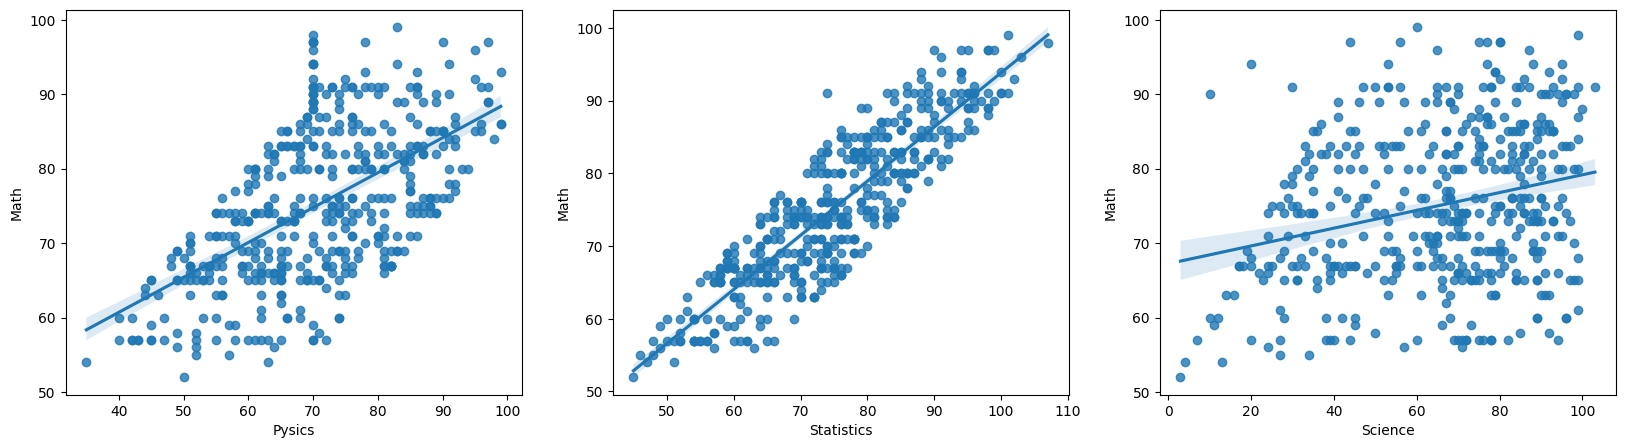

In [79]:
# membuat scatterplot setiap fitur (selain math) terhadap target (math)
fig, axis = plt.subplots(1,3,figsize=(20,5))
sns.regplot(data=df, x='Pysics', y='Math', ax=axis[0])
sns.regplot(data=df, x='Statistics', y='Math', ax=axis[1])
sns.regplot(data=df, x='Science', y='Math', ax=axis[2])

In [80]:
df.corr()

,Pysics,Science,Statistics,Math
Pysics,1.000000,0.111695,0.484287,0.581272
Science,0.111695,1.000000,0.267111,0.262315
Statistics,0.484287,0.267111,1.000000,0.879755
Math,0.581272,0.262315,0.879755,1.000000


In [82]:
# pemisahab fitur dan targer
prediktor = ['Pysics', 'Science', 'Statistics']
X = df[prediktor].values #prekditor/ fitur
y = df['Math'] #target/ output/ criteria

Model Selection

In [83]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=10)

In [84]:
print(x_train.shape)
print(x_test.shape)

(368, 3)
(93, 3)


In [85]:
# Metrik untuk melihat ketepatan prediksi
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [88]:
# Linear Regresi
from sklearn.linear_model import LinearRegression

LIR = LinearRegression()
LIR.fit(x_train, y_train)
y_pred_test = LIR.predict(x_test)
y_pred_train = LIR.predict(x_train)

MAE_LIR_train = mean_absolute_error(y_pred_train, y_train)
MAE_LIR_test = mean_absolute_error(y_pred_test, y_test)
r2_LIR_train = r2_score(y_pred_train, y_train)
r2_LIR_test = r2_score(y_pred_test, y_test)

print("MAE Linear Regression Train ", MAE_LIR_train)
print("MAE Linear Regression Test ", MAE_LIR_test)
print("R2 Linear Regression Train ", r2_LIR_train)
print("R2 Linear Regression Test ", r2_LIR_test)

MAE Linear Regression Train  3.918060862249362
MAE Linear Regression Test  3.242210446182917
R2 Linear Regression Train  0.7396467720186026
R2 Linear Regression Test  0.8401514373394536


In [90]:
# Logistik Regresi
from sklearn.linear_model import  LogisticRegression

LOR = LogisticRegression(solver='newton-cg', max_iter=10000) #liblinear, lbfgs,saga, sag
LOR.fit(x_train, y_train)
y_pred_test = LOR.predict(x_test)
y_pred_train = LOR.predict(x_train)

MAE_LOR_train = mean_absolute_error(y_pred_train, y_train)
MAE_LOR_test = mean_absolute_error(y_pred_test, y_test)
r2_LOR_train = r2_score(y_pred_train, y_train)
r2_LOR_test = r2_score(y_pred_test, y_test)

print("MAE Logistik Regression Train ", MAE_LOR_train)
print("MAE Logistik Regression Test ", MAE_LOR_test)
print("R2 Logistik Regression Train ", r2_LOR_train)
print("R2 Logistik Regression Test ", r2_LOR_test)

MAE Logistik Regression Train  4.130434782608695
MAE Logistik Regression Test  3.6021505376344085
R2 Logistik Regression Train  0.7256059944551854
R2 Logistik Regression Test  0.8286220074182309


In [95]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

DT = DecisionTreeRegressor(max_depth=5)
DT.fit(x_train, y_train)
y_pred_test = DT.predict(x_test)
y_pred_train = DT.predict(x_train)

MAE_DT_train = mean_absolute_error(y_pred_train, y_train)
MAE_DT_test = mean_absolute_error(y_pred_test, y_test)
r2_DT_train = r2_score(y_pred_train, y_train)
r2_DT_test = r2_score(y_pred_test, y_test)

print("MAE Decision Tree Regression Train ", MAE_DT_train)
print("MAE Decision Tree Regression Test ", MAE_DT_test)
print("R2 Decision Tree Regression Train ", r2_DT_train)
print("R2 Decision Tree Regression Test ", r2_DT_test)

MAE Decision Tree Regression Train  3.096173189125273
MAE Decision Tree Regression Test  3.191402600948122
R2 Decision Tree Regression Train  0.8193160259319052
R2 Decision Tree Regression Test  0.8324903495338926


In [97]:
# Support Vector Machine for Regression
from sklearn.svm import SVR

SVR = SVR()
SVR.fit(x_train, y_train)
y_pred_test = SVR.predict(x_test)
y_pred_train = SVR.predict(x_train)

MAE_SVR_train = mean_absolute_error(y_pred_train, y_train)
MAE_SVR_test = mean_absolute_error(y_pred_test, y_test)
r2_SVR_train = r2_score(y_pred_train, y_train)
r2_SVR_test = r2_score(y_pred_test, y_test)

print("MAE Support Vector Machine Regression Train ", MAE_SVR_train)
print("MAE Support Vector Machine Regression Test ", MAE_SVR_test)
print("R2 Support Vector Machine Regression Train ", r2_SVR_train)
print("R2 Support Vector Machine Regression Test ", r2_SVR_test)

MAE Support Vector Machine Regression Train  4.198082805638276
MAE Support Vector Machine Regression Test  3.9881646322072357
R2 Support Vector Machine Regression Train  0.5248582678926004
R2 Support Vector Machine Regression Test  0.5865997822855071


In [94]:
y_test.shape

(93,)

## Hyperparameters Tuning

In [100]:
from sklearn.model_selection import GridSearchCV

model = DecisionTreeRegressor()
param = {
    'max_depth': list(range(1, 20, 1)), # kedalaman batang pohon
    'splitter': ['best', 'random'], # cara splitting sampel
    'min_samples_leaf': list(range(1, 20, 1)), # banyak sample pada akhir
}

gs = GridSearchCV(model, param_grid = param, cv=10, verbose=1)

gs.fit(x_train, y_train)
print(gs.best_params_)

Fitting 10 folds for each of 722 candidates, totalling 7220 fits
{'max_depth': 15, 'min_samples_leaf': 7, 'splitter': 'random'}


In [102]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

DT = DecisionTreeRegressor(max_depth=14)
DT.fit(x_train, y_train)
y_pred_train = DT.predict(x_train)
y_pred_test = DT.predict(x_test)

MAE_DT_train = mean_absolute_error(y_pred_train, y_train)
MAE_DT_test = mean_absolute_error(y_pred_test, y_test)
r2_DT_train = r2_score(y_pred_train, y_train)
r2_DT_test = r2_score(y_pred_test, y_test)

print(MAE_DT_train)
print(MAE_DT_test)
print(r2_DT_train)
print(r2_DT_train)

0.002717391304347826
4.591397849462366
0.9999874828833532
0.9999874828833532


In [103]:
y_test.shape

(93,)

## Check Model Prediction

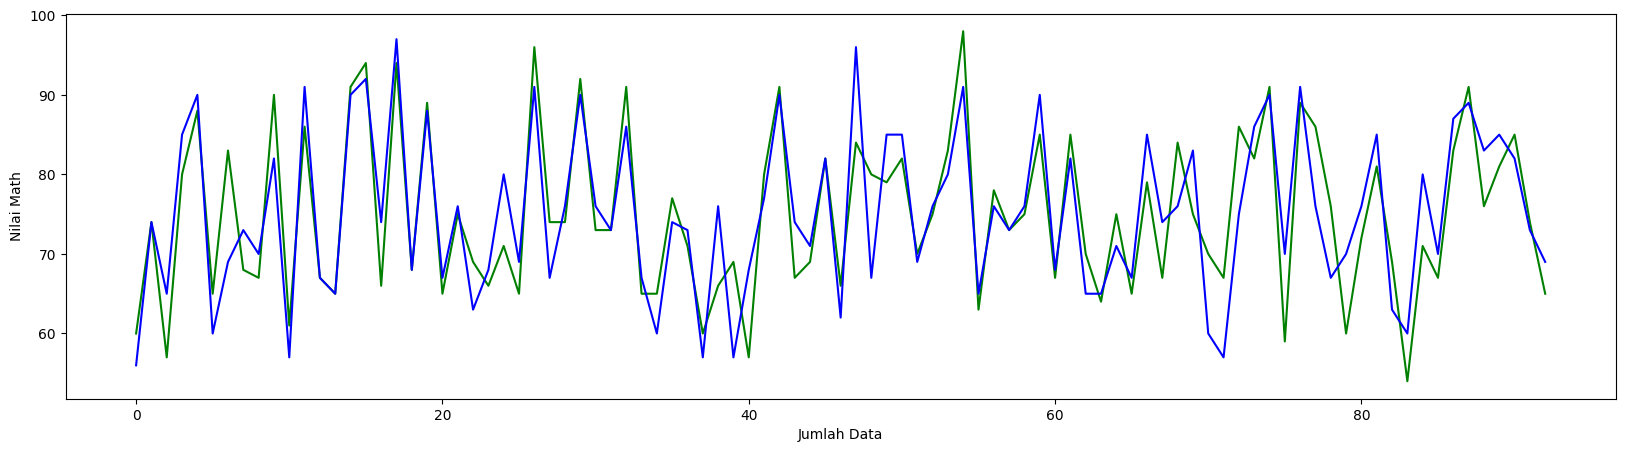

In [106]:
plt.figure(figsize=(20, 5))

w = [i for i in range(0,93,1)]  # dimulai dari 0, untuk 93 titik (banyaknya data test), dengang kelipatan 1

plt.plot(w, y_test, color='g')  #nilai target aktual
plt.plot(w, y_pred_test, color='b')  # nilai prediksi
plt.xlabel('Jumlah Data')
plt.ylabel('Nilai Math')
plt.show()

In [107]:
prediktor

['Pysics', 'Science', 'Statistics']

In [112]:
# fungsi untuk prediksi
def prediksi(Py, Sc, St, Model):
  pred = np.array([Py, Sc, St])
  pred = np.reshape(pred, (-1, 3))
  prediction = Model.predict(pred).item()
  return prediction

In [117]:
prediksi(52,38,56, DT)

57.0

In [116]:
df.head(3)

,Pysics,Science,Statistics,Math
0,50,32,60,68
1,76,39,69,67
2,52,38,56,57
